# HOLA, ignoren esto, este notebook solo existe para sacar imagenes para el informe

Coupler 50/50

\begin{equation*}
\mathbf{U} =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & j \\
j & 1
\end{pmatrix}
\end{equation*}


Phase shifter

\begin{equation*}
\mathbf{Phase}(\phi) =
\begin{pmatrix}
e^{j\phi} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}

Delay

\begin{equation*}
\mathbf{Delay}(\beta L) =
\begin{pmatrix}
e^{-j\beta L} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}


Funcion de transferencia del MZI

Tomando 
\begin{equation*}
P = e^{j\phi} 
\end{equation*}

\begin{equation*}
D = e^{-j\beta L} 
\end{equation*}

Entonces: 

\begin{equation}
H = U \cdot Phase \cdot Delay \cdot U
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
-1 + e^{j\phi}e^{-j\beta L } & j\left(1 + e^{j\phi}e^{-j\beta L}\right) \\
j\left(1 + e^{j\phi}e^{-j\beta L} \right) & 1 - e^{j\phi}e^{-j\beta L} 
\end{pmatrix}
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
PD - 1 & j(1 + PD) \\
j(1 + PD) & 1 - PD
\end{pmatrix}
\end{equation}



---

Coupler 50/50

\begin{equation*}
\mathbf{U} =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & j \\
j & 1
\end{pmatrix}
\end{equation*}

Phase shifter

\begin{equation*}
\mathbf{P}(\phi) =
\begin{pmatrix}
e^{j\phi} & 0 \\
0 & 1
\end{pmatrix}
%---------------
\quad \Rightarrow \quad
%---------------
P(\beta L) =
\begin{pmatrix}
e^{-j\beta L} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}

Funcion de transferencia del MZI

\begin{equation}
H = U \cdot P \cdot U
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
e^{-j\beta L} - 1               & j\left( e^{-j\beta L} + 1 \right) \\
j\left(e^{-j\beta L} + 1 \right) & 1 - e^{-j\beta L}
\end{pmatrix}
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
D - 1 & j(D + 1) \\
j(D + 1) & 1 - D
\end{pmatrix}
\end{equation}

\begin{equation}
D = e^{-j\beta L}
\end{equation}

Vector de entrada

\begin{equation*}
E_{\text{in}} =
\begin{pmatrix}
1 \\
0
\end{pmatrix}
\end{equation*}

\begin{equation*}
E_{\text{out}} = H \cdot E_{\text{in}}
\end{equation*}

Salidas

\begin{equation*}
H_{11} = \frac{1}{2}\left( 1 + e^{-j\beta L}\right) = \frac{1}{2}(1 + D)
\end{equation*}

\begin{equation*}
H_{21} = \frac{j}{2}\left( 1 - e^{-j\beta L}\right) = \frac{j}{2}(1 - D)
\end{equation*}

Salidas en magnitud

\begin{equation*}
\left|H_{11}\right|^2 = \frac{1}{2}\left(1 - \cos(\beta L)\right) = \sin^2\left(\frac{\beta L}{2}\right)
\end{equation*}

\begin{equation*}
\left|H_{21}\right|^2 = \frac{1}{2}\left(1 + \cos(\beta L)\right) = \cos^2\left(\frac{\beta L}{2}\right)
\end{equation*}

# Estudio individual del comportamiento de los MZI

In [1]:
import numpy as np
from sympy import symbols, Matrix, exp, I, simplify
import matplotlib.pyplot as plt

In [3]:
n_eff0 = 1.6049 
n_g = 4.18

wvl0=1.55e-6
wvlf=1.6e-6
wvli=1.5e-6


FSR=(wvlf-wvli)/4
L=wvl0**2/(n_g*FSR)


wvl=np.linspace(1500e-9,1599e-9,2000)

print(f"La longitud L debe ser {np.round(L*1e9,3)} nm")

# Hallamos el indice efectivo para cada longitud de onda 
n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
beta=2*np.pi*n_eff/wvl


La longitud L debe ser 22990.431 nm


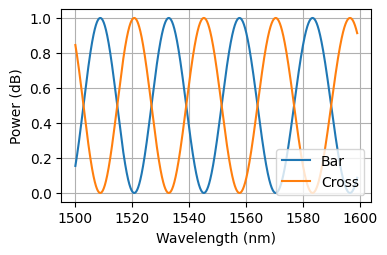

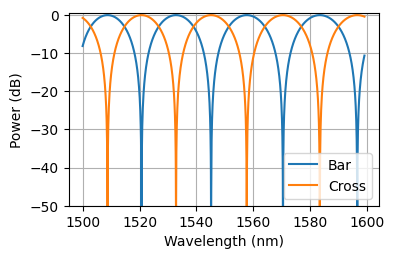

In [18]:
D = np.exp(-1j * beta * L)

# ---- coeficientes ----
# Esto ocurria cuando se entraba por la entrada 1
# mzi_1_bar   = 0.5 * (D-1)
# mzi_1_cross = 0.5j * (D+1)
# Se usa la entrada dos
mzi_1_cross   = 0.5j * (D+1)
mzi_1_bar = 0.5 * (1-D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)



# ---- gráfica ----
# plt.figure(figsize=(4,2.5))
plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_bar, label='Bar')
plt.plot(wvl*1e9, P_cross, label='Cross')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
#plt.title('Respuesta espectral MZI')
# plt.ylim(-50,0.5)
plt.legend(loc="lower right")
plt.grid()
# plt.savefig('IMG/Salidas_MZI_In.png', bbox_inches='tight')

# ---- gráfica ----
# plt.figure(figsize=(4,2.5))
plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
#plt.title('Respuesta espectral MZI')
plt.ylim(-50,0.5)
plt.legend(loc="lower right")
plt.grid()
# plt.savefig('IMG/Salidas_MZI_In.png', bbox_inches='tight')

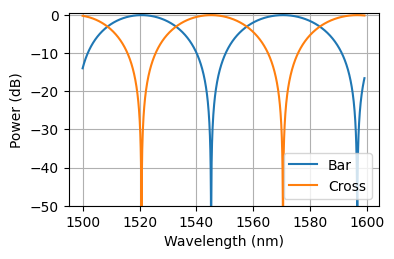

In [12]:
D = np.exp(-1j * beta * L/2)

# ---- coeficientes ----
# Esto ocurria cuando se entraba por la entrada 1
# mzi_1_bar   = 0.5 * (D-1)
# mzi_1_cross = 0.5j * (D+1)
# Se usa la entrada dos
mzi_1_cross   = 0.5j * (D+1)
mzi_1_bar = 0.5 * (1-D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
# plt.figure(figsize=(4,2.5))
plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
#plt.title('Respuesta espectral MZI')
plt.ylim(-50,0.5)
plt.legend(loc="lower right")
plt.grid()
plt.savefig('IMG/Salidas_TB.png', bbox_inches='tight')

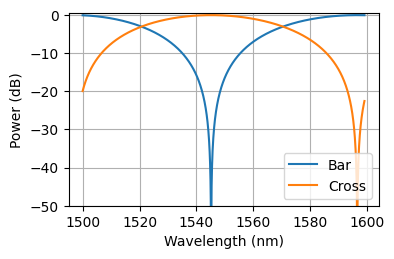

In [13]:
D = np.exp(-1j * beta * L/4)

# ---- coeficientes ----
# Esto ocurria cuando se entraba por la entrada 1
# mzi_1_bar   = 0.5 * (D-1)
# mzi_1_cross = 0.5j * (D+1)
# Se usa la entrada dos
mzi_1_cross   = 0.5j * (D+1)
mzi_1_bar = 0.5 * (1-D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
# plt.figure(figsize=(4,2.5))
plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
#plt.title('Respuesta espectral MZI')
plt.ylim(-50,0.5)
plt.legend(loc="lower right")
plt.grid()
plt.savefig('IMG/Salidas_MZI_Out.png', bbox_inches='tight')

# Salida 1
---

In [5]:
n_eff0 = 1.6049 
n_g = 4.18

wvl0=1.55e-6
wvlf=1.6e-6
wvli=1.5e-6


FSR=(wvlf-wvli)/4
L=wvl0**2/(n_g*FSR)


wvl=np.linspace(1500e-9,1599e-9,2000)

print(f"La longitud L debe ser {np.round(L*1e9,3)} nm")

# Hallamos el indice efectivo para cada longitud de onda 
n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
beta=2*np.pi*n_eff/wvl

La longitud L debe ser 22990.431 nm


Deseo graficar solo la salida bar, esto con el fin de demostrar como se propaga hasta la salida 1

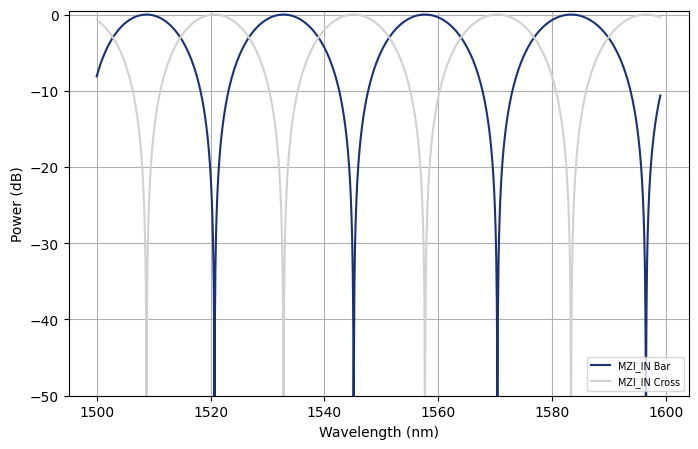

In [6]:
D = np.exp(-1j * beta * L)

# ---- coeficientes ----
# Esto ocurria cuando se entraba por la entrada 1
# mzi_1_bar   = 0.5 * (D-1)
# mzi_1_cross = 0.5j * (D+1)
# Se usa la entrada dos
mzi_1_bar = 0.5 * (1-D)
mzi_1_cross = 0.5j * (D+1)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_bar_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_cross_dB, color="#D1D1D1", label='MZI_IN Cross')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_ODD.png', bbox_inches='tight')

### Totalizador graficas

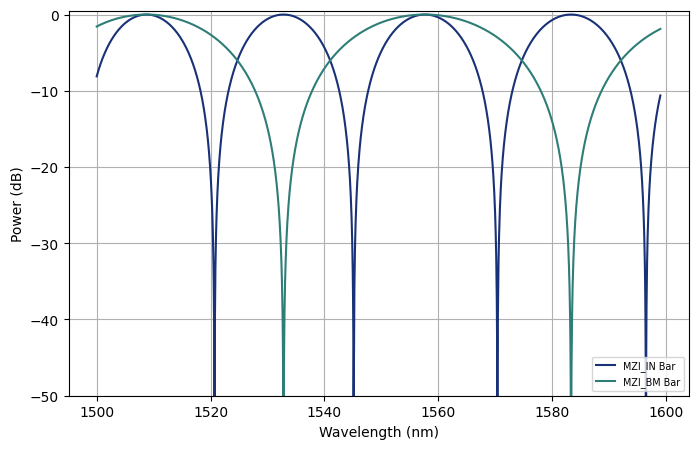

In [15]:
D  = np.exp(-1j * beta * L)
D1 = np.exp(-1j * beta * L/2)
D2 = np.exp(-1j * beta * L/4)

# PS = np.exp(1j*(np.pi/2)*0)

PS = np.exp(1j*np.pi*(1/2))
PS_1_5=np.exp(1j*-0.26*np.pi)
# PS_1_5=np.exp(1j*np.pi*(-1/2)) # Es el que aparece en la simulacion original, de igual modo no cambia mucho

# ---- coeficientes ----
mzi_in_bar = 0.5 * (1-D)
mzi_bm_bar = 0.5 * (1-D1*PS)
mzi_1_5_bar = 0.5 * (1-D2*PS_1_5)
# Cross prueba
# mzi_1_5_bar = 1j*0.5 * (1+D2*PS_1_5)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_in_bar_dB = 10 * np.log10( np.abs(mzi_in_bar)**2 + eps)
P_mzi_bm_bar_dB = 10 * np.log10( np.abs(mzi_bm_bar)**2 + eps)
P_mzi_1_5_bar_dB = 10 * np.log10( np.abs(mzi_1_5_bar)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_mzi_in_bar_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_mzi_bm_bar_dB, color="#2e7d77", label='MZI_BM Bar')
# plt.plot(wvl*1e9, P_mzi_1_5_bar_dB, color="#a83787", label='MZI_1_5 Bar')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_BM_BAR.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_5_BAR.png', bbox_inches='tight')


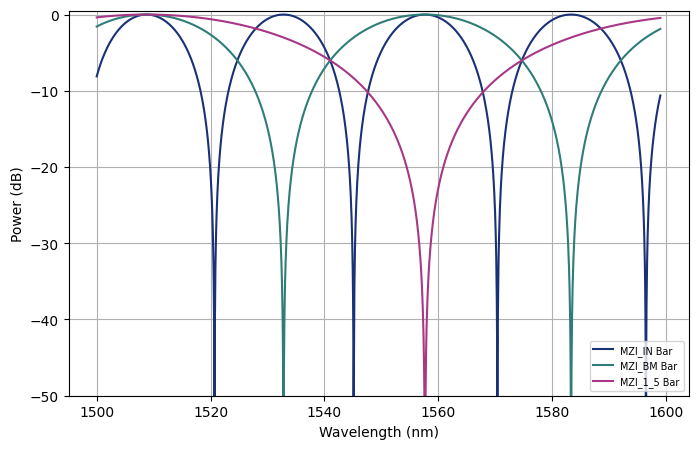

In [ ]:
D  = np.exp(-1j * beta * L)
D1 = np.exp(-1j * beta * L/2)
D2 = np.exp(-1j * beta * L/4)

# PS = np.exp(1j*(np.pi/2)*0)

PS = np.exp(1j*np.pi*(1/2))
PS_1_5=np.exp(1j*1.75*np.pi)  # -0.26
# PS_1_5=np.exp(1j*np.pi*(-1/2)) # Es el que aparece en la simulacion original, de igual modo no cambia mucho

# ---- coeficientes ----
mzi_in_bar = 0.5 * (1-D)
mzi_bm_bar = 0.5 * (1-D1*PS)
mzi_1_5_bar = 0.5 * (1-D2*PS_1_5)
# Cross prueba
# mzi_1_5_bar = 1j*0.5 * (1+D2*PS_1_5)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_in_bar_dB = 10 * np.log10( np.abs(mzi_in_bar)**2 + eps)
P_mzi_bm_bar_dB = 10 * np.log10( np.abs(mzi_bm_bar)**2 + eps)
P_mzi_1_5_bar_dB = 10 * np.log10( np.abs(mzi_1_5_bar)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_mzi_in_bar_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_mzi_bm_bar_dB, color="#2e7d77", label='MZI_BM Bar')
plt.plot(wvl*1e9, P_mzi_1_5_bar_dB, color="#a83787", label='MZI_1_5 Bar')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_BM_BAR.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_5_BAR.png', bbox_inches='tight')


Pequeño analisis para extraer informacion de los picos

In [16]:
mask = (wvl >= 1500e-9) & (wvl <= 1520e-9)

wvl_masked = wvl[mask]
# p_masked = P_mzi_bm_bar_dB[mask]
p_masked = P_mzi_in_bar_dB[mask]

# Pico dentro de la ventana
idx_max = np.argmax(p_masked)

wvl_peak = wvl_masked[idx_max]
p_peak = p_masked[idx_max]

print(f"Pico en wvl = {wvl_peak}")
print(f"Valor máximo f = {p_peak}")

Pico en wvl = 1.5087658829414707e-06
Valor máximo f = -2.8950391490527627e-05


Para el MZI BTM este originalmente se encontraba a una longitud de onda de 1520,7013 nm, con el desplazamiento de pi/2 se desplazo a una posición de 1508.7658 nm.

Considerando el FSR que tiene el MZI seria por medio de la iferencia entre sus picos 1557.6468 nm y 1508.7658 nm

In [14]:
FSR = 1557.6468 - 1508.7658
wvl_shift = 1520.7013 - 1508.7658

# Imprimir resultados
print("FSR =", FSR)
print("wvl_shift =", wvl_shift)

FSR = 48.881000000000085
wvl_shift = 11.935500000000047


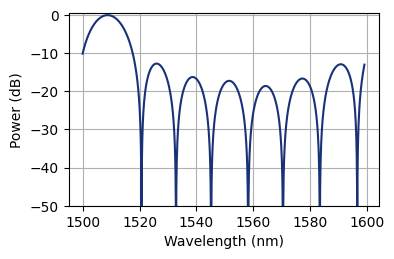

In [ ]:
MZI_1_5_out = mzi_in_bar * mzi_bm_bar * mzi_1_5_bar
# MZI_1_5_out = mzi_in_bar * mzi_bm_bar * mzi_1_5_bar

eps = 1e-12
P_MZI_1_5_out_dB = 10 * np.log10( np.abs(MZI_1_5_out)**2 + eps)

# ---- gráfica ----
# plt.figure(figsize=(10,5))
plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_MZI_1_5_out_dB, color="#193177")

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
#plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_1_etapa1.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_etapa2.png', bbox_inches='tight')
plt.savefig('IMG/OUT_1_etapa3.png', bbox_inches='tight')

plt.show()

# Salida 3
---

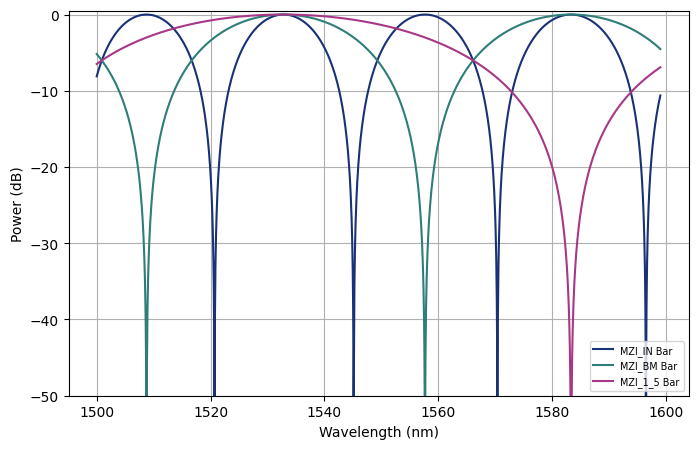

In [38]:
D  = np.exp(-1j * beta * L)
D1 = np.exp(-1j * beta * L/2)
D2 = np.exp(-1j * beta * L/4)

# PS = np.exp(1j*(np.pi/2)*0)

PS = np.exp(1j*np.pi*(1/2))
PS_3_7=np.exp(1j*1.25*np.pi)
# PS_1_5=np.exp(1j*np.pi*(-1/2)) # Es el que aparece en la simulacion original, de igual modo no cambia mucho

# ---- coeficientes ----
mzi_in_bar = 0.5 * (1-D)
mzi_bm_cross = 1j*0.5 * (D1*PS+1)
mzi_3_7_bar = 0.5 * (1-D2*PS_3_7)
# Cross prueba
# mzi_1_5_bar = 1j*0.5 * (1+D2*PS_1_5)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_in_bar_dB = 10 * np.log10( np.abs(mzi_in_bar)**2 + eps)
P_mzi_bm_cross_dB = 10 * np.log10( np.abs(mzi_bm_cross)**2 + eps)
P_mzi_3_7_bar_dB = 10 * np.log10( np.abs(mzi_3_7_bar)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_mzi_in_bar_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_mzi_bm_cross_dB, color="#2e7d77", label='MZI_BM Bar')
plt.plot(wvl*1e9, P_mzi_3_7_bar_dB, color="#a83787", label='MZI_1_5 Bar')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_BM_BAR.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_5_BAR.png', bbox_inches='tight')


# Salida 2
---

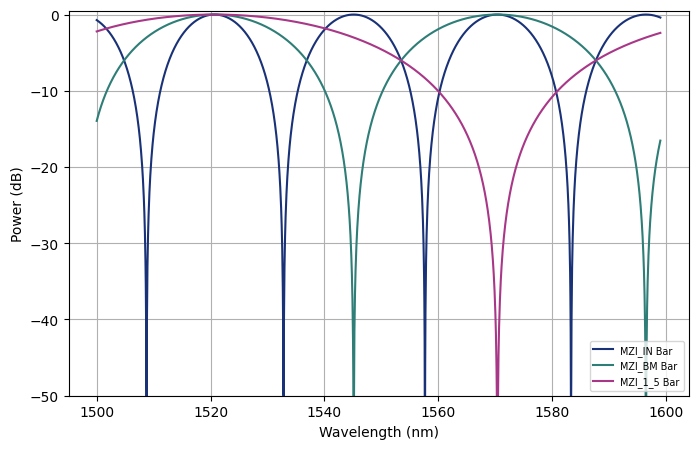

In [90]:
D  = np.exp(-1j * beta * L)
D1 = np.exp(-1j * beta * L/2)
D2 = np.exp(-1j * beta * L/4)

# PS = np.exp(1j*(np.pi/2)*0)

PS_TP = np.exp(1j*0)
PS_2_6= np.exp(1j*1.5*np.pi)
# PS_1_5=np.exp(1j*np.pi*(-1/2)) # Es el que aparece en la simulacion original, de igual modo no cambia mucho

# ---- coeficientes ----
mzi_in_cross = 1j*0.5 * (D+1)
mzi_tp_bar = 0.5 * (1-D1*PS_TP)
mzi_2_6_bar = 0.5 * (1-D2*PS_2_6)
# Cross prueba
# mzi_1_5_bar = 1j*0.5 * (1+D2*PS_1_5)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_in_cross_dB = 10 * np.log10( np.abs(mzi_in_cross)**2 + eps)
P_mzi_tp_bar_dB = 10 * np.log10( np.abs(mzi_tp_bar)**2 + eps)
P_mzi_2_6_bar_dB = 10 * np.log10( np.abs(mzi_2_6_bar)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_mzi_in_cross_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_mzi_tp_bar_dB, color="#2e7d77", label='MZI_BM Bar')
plt.plot(wvl*1e9, P_mzi_2_6_bar_dB, color="#a83787", label='MZI_1_5 Bar')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_BM_BAR.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_5_BAR.png', bbox_inches='tight')


# Salida 4
---

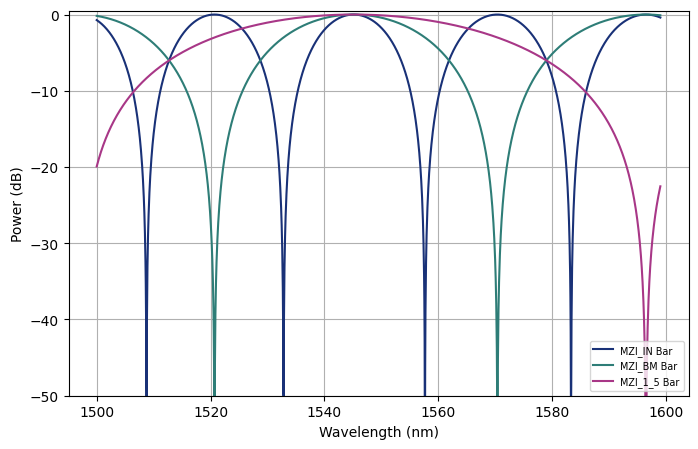

In [96]:
D  = np.exp(-1j * beta * L)
D1 = np.exp(-1j * beta * L/2)
D2 = np.exp(-1j * beta * L/4)

# PS = np.exp(1j*(np.pi/2)*0)

PS_TP = np.exp(1j*0)
PS_4_8= np.exp(1j*1*np.pi)
# PS_1_5=np.exp(1j*np.pi*(-1/2)) # Es el que aparece en la simulacion original, de igual modo no cambia mucho

# ---- coeficientes ----
mzi_in_cross = 1j*0.5 * (D+1)
mzi_tp_cross = 1j*0.5 * (D1*PS_TP+1)
mzi_4_8_bar = 0.5 * (1-D2*PS_4_8)
# Cross prueba
# mzi_1_5_bar = 1j*0.5 * (1+D2*PS_1_5)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_in_cross_dB = 10 * np.log10( np.abs(mzi_in_cross)**2 + eps)
P_mzi_tp_cross_dB = 10 * np.log10( np.abs(mzi_tp_cross)**2 + eps)
P_mzi_4_8_bar_dB = 10 * np.log10( np.abs(mzi_4_8_bar)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(8,5))
# plt.figure(figsize=(4,2.5))
plt.plot(wvl*1e9, P_mzi_in_cross_dB, color="#193177", label='MZI_IN Bar')
plt.plot(wvl*1e9, P_mzi_tp_cross_dB, color="#2e7d77", label='MZI_BM Bar')
plt.plot(wvl*1e9, P_mzi_4_8_bar_dB, color="#a83787", label='MZI_1_5 Bar')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dB)')
plt.ylim(-50,0.5)
plt.legend(fontsize='x-small', loc="lower right")
plt.grid()
# plt.savefig('IMG/OUT_BM_BAR.png', bbox_inches='tight')
# plt.savefig('IMG/OUT_1_5_BAR.png', bbox_inches='tight')


# Interconexion MZIs

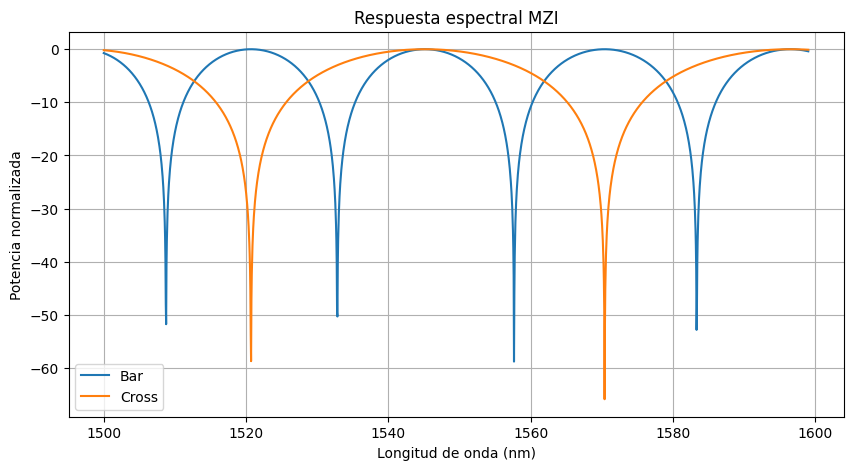

In [ ]:
D  = np.exp(-1j * beta * L)
D2 = np.exp(-1j * beta * L/2)


# PS = np.exp(1j*(np.pi/2)*0)

PS = np.exp(1j*0)

# ---- coeficientes ----
mzi_1_cross = 0.5j * (D+1)
mzi_2_cross = 0.5j * (D2*PS+1)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_1_cross_dB = 10 * np.log10( np.abs(mzi_1_cross)**2 + eps)
P_mzi_2_cross_dB = 10 * np.log10( np.abs(mzi_2_cross)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_mzi_1_cross_dB, label='Bar')
plt.plot(wvl*1e9, P_mzi_2_cross_dB, label='Cross')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

# MZI_1_5_out = mzi_1_bar * mzi_2_bar
# P_MZI_1_5_out_dB = 10 * np.log10( np.abs(MZI_1_5_out)**2 + eps)

# # ---- gráfica ----
# plt.figure(figsize=(10,5))
# plt.plot(wvl*1e9, P_MZI_1_5_out_dB , label='MZI_1_5_out')

# plt.xlabel('Longitud de onda (nm)')
# plt.ylabel('Potencia normalizada')
# plt.title('Respuesta espectral MZI')
# plt.legend()
# plt.grid()

# plt.show()

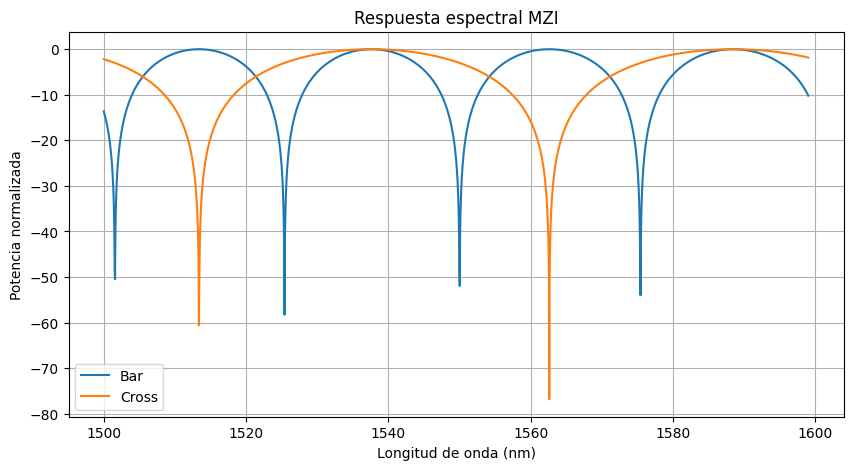

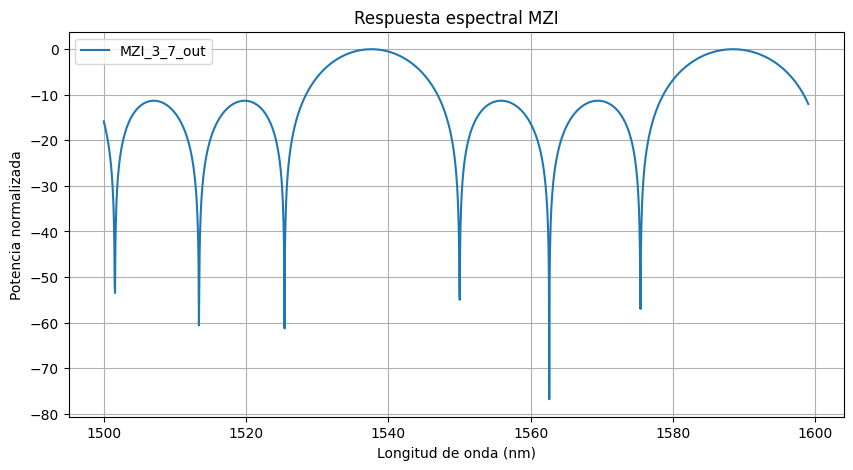

In [30]:
D  = np.exp(-1j * beta * L)
D2 = np.exp(-1j * beta * L/2)

# PS = np.exp(1j*(np.pi/2)*0)

PS = np.exp(1j*np.pi/2)

# ---- coeficientes ----
mzi_1_bar = 0.5 * (D-1) 
mzi_2_cross = 0.5j * (D2*PS+1)

# ---- evitar log(0) ----
eps = 1e-12
P_mzi_1_bar_dB = 10 * np.log10( np.abs(mzi_1_bar)**2 + eps)
P_mzi_2_cross_dB = 10 * np.log10( np.abs(mzi_2_cross)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_mzi_1_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_mzi_2_cross_dB, label='Cross')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

MZI_3_7_out = mzi_1_bar * mzi_2_cross
P_MZI_3_7_out_dB = 10 * np.log10( np.abs(MZI_3_7_out)**2 + eps)

# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_MZI_3_7_out_dB , label='MZI_3_7_out')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

Creo que ocurrirá un problema en el sentido de que no estoy generando los nodos que necesito para la construcción del filtro, quiero ver que ocurriría con un montaje en cascada



In [16]:
import numpy as np

def cascade_mzi(wvl, Ls, n_eff=1.6, Ein=(1.0, 0.0)):
    """
    wvl : array de longitudes de onda [m]
    Ls  : lista/array de longitudes de cada MZI [m]
    n_eff : índice efectivo
    Ein : (a0, b0) campo de entrada
    
    Returns:
        E_bar, E_cross, P_bar, P_cross (arrays vs wvl)
    """
    # estado inicial (arrays complejos del tamaño de wvl)
    a = np.full_like(wvl, Ein[0], dtype=complex)
    b = np.full_like(wvl, Ein[1], dtype=complex)

    beta = 2*np.pi*n_eff / wvl

    for L in Ls:
        D = np.exp(-1j * beta * L)

        a_next = 0.5 * ((1 + D)*a + 1j*(1 - D)*b)
        b_next = 0.5 * (1j*(1 - D)*a + (1 + D)*b)

        a, b = a_next, b_next

    E_bar, E_cross = a, b
    P_bar = np.abs(E_bar)**2
    P_cross = np.abs(E_cross)**2

    return E_bar, E_cross, P_bar, P_cross

In [ ]:
# parámetros de diseño

# deep waveguide para una longitud de onda de 1550 nm  core=1.2 thckness=300nm sinx--> sin y sio2

n_eff0 = 2.38 # 1.6049 
n_g = 4.28 # 4.18

# NICOOO AQUI LO DE EL n_eff Y EL n_g

wvl0=1.55e-6
wvlf=1.6e-6
wvli=1.5e-6


FSR=(wvlf-wvli)/4
L=wvl0**2/(n_g*FSR)


wvl=np.linspace(1500e-9,1599e-9,2000)

print(f"La longitud L debe ser {np.round(L*1e9,3)} nm o {np.round(L*1e6,3)} um")

La longitud L debe ser 22453.271 nm o 22.453 um


In [108]:
# Hallamos el indice efectivo para cada longitud de onda 
n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
beta=2*np.pi*n_eff/wvl

# Campo de entrada In

In=1

# Delay de cada etapa

D=np.exp(-1j*beta*L)
D1=np.exp(-1j*beta*L/2)
D2=np.exp(-1j*beta*L/4)

# Phase shifter de cada etapa

PS_BM = np.exp(1j*np.pi*(1/2))
PS_TP = np.exp(1j*0)

PS_1_5=np.exp(1j*1.75*np.pi)
PS_3_7=np.exp(1j*1.25*np.pi)

PS_2_6= np.exp(1j*1.5*np.pi)
PS_4_8= np.exp(1j*1*np.pi)

# Salidas MZI

mzi_in_bar    = 0.5 * (1-D)
mzi_in_cross  = 1j*0.5 * (D+1)

mzi_bm_bar    = 0.5 * (1-D1*PS_BM)
mzi_bm_cross  = 1j*0.5 * (D1*PS_BM+1)

mzi_tp_bar    = 0.5 * (1-D1*PS_TP)
mzi_tp_cross  = 1j*0.5 * (D1*PS_TP+1)

# Salidas impares

mzi_1_5_bar   = 0.5 * (1-D2*PS_1_5)
mzi_1_5_cross = 1j*0.5 * (D2*PS_1_5+1)

mzi_3_7_bar   = 0.5 * (1-D2*PS_3_7)
mzi_3_7_cross = 1j*0.5 * (D2*PS_3_7+1)

# Salidas pares

mzi_2_6_bar   = 0.5 * (1-D2*PS_2_6)
mzi_2_6_cross = 1j*0.5 * (D2*PS_2_6+1)

mzi_4_8_bar   = 0.5 * (1-D2*PS_4_8)
mzi_4_8_cross = 1j*0.5 * (D2*PS_4_8+1)

# -------------------------------
# Salidas Multiplexor
# -------------------------------

Out1 = In * mzi_in_bar * mzi_bm_bar * mzi_1_5_bar
Out3 = In * mzi_in_bar * mzi_bm_cross * mzi_3_7_bar
Out5 = In * mzi_in_bar * mzi_bm_bar * mzi_1_5_cross
Out7 = In * mzi_in_bar * mzi_bm_cross * mzi_3_7_cross

Out2 = In * mzi_in_cross * mzi_tp_bar * mzi_2_6_bar
Out4 = In * mzi_in_cross * mzi_tp_cross * mzi_4_8_bar
Out6 = In * mzi_in_cross * mzi_tp_bar * mzi_2_6_cross
Out8 = In * mzi_in_cross * mzi_tp_cross * mzi_4_8_cross


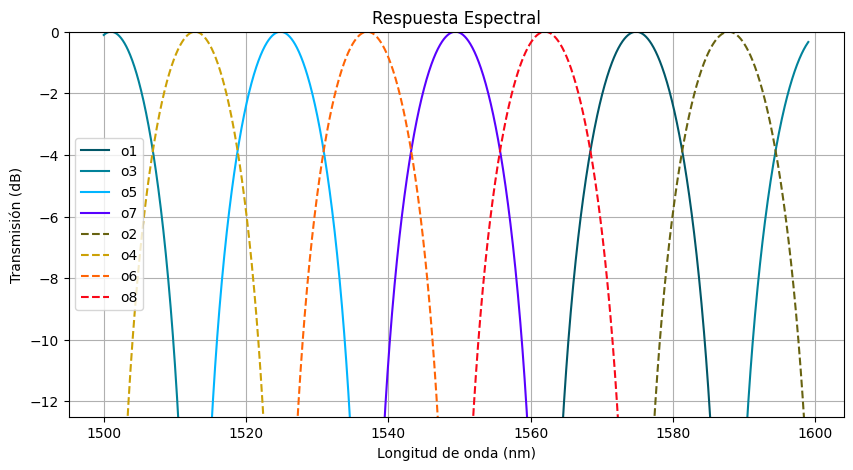

In [109]:
plt.figure(figsize=(10, 5))
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out1)**2), color="#015768", label='o1')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out3)**2), color="#01829a", label='o3')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out5)**2), color="#00b5ff", label='o5')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out7)**2), color="#5801fe", label='o7')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out2)**2), linestyle='--', color="#676210", label='o2')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out4)**2), linestyle='--', color="#cca106", label='o4')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out6)**2), linestyle='--', color="#ff6405", label='o6')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out8)**2), linestyle='--', color="#f90818", label='o8')
plt.ylim(-12.5,0)
plt.legend()
plt.title("Respuesta Espectral")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True)
plt.show()

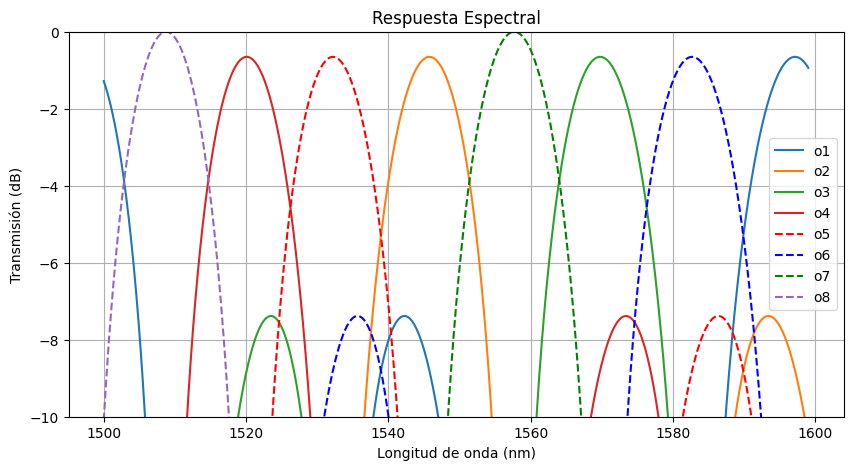

In [4]:

# Hallamos el indice efectivo para cada longitud de onda 
n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
beta=2*np.pi*n_eff/wvl

# Campo de entrada In

In=1

# Delay de cada etapa

D=np.exp(-1j*beta*L)
D1=np.exp(-1j*beta*L/2)
D2=np.exp(-1j*beta*L/4)

# Phase shifter de cada etapa

PS_up=np.exp(1j*0)
PS_down=np.exp(1j*np.pi*(1/2))

PS2=np.exp(1j*np.pi*(3/4))
PS3=np.exp(1j*np.pi*(-1/4)) # 3/4 - 1

PS4=np.exp(1j*np.pi*(1/2))
PS5=np.exp(1j*-0.26*np.pi) # 1/2 - 1

# salidas halladas anteriormente

Out1=1j**3/8 * In * (D+1)*(D1*PS_up+1)*(D2*PS2+1)
Out2=1j**2/8 * In * (D+1)*(D1*PS_up+1)*(1-D2*PS2)

Out3=1j**2/8 * In * (D+1)*(1-D1*PS_up)*(D2*PS3+1)
Out4=  -1j/8 * In * (D+1)*(1-D1*PS_up)*(1-D2*PS3)

Out5=1j**2/8 * In * (1-D)*(D1*PS_down+1)*(D2*PS4+1)
Out6=   1j/8 * In * (1-D)*(D1*PS_down+1)*(1-D2*PS4)

Out7=   1j/8 * In * (1-D)*(1-D1*PS_down)*(D2*PS5+1)
Out8=    1/8 * In * (1-D)*(1-D1*PS_down)*(1-D2*PS5)

# Simualción del comportamiento de cada entrada

plt.figure(figsize=(10, 5))
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out1)**2),label='o1')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out2)**2),label='o2')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out3)**2),label='o3')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out4)**2),label='o4')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out5)**2),linestyle='--',color='r',label='o5')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out6)**2),linestyle='--',color='b',label='o6')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out7)**2),linestyle='--',color='g',label='o7')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out8)**2),linestyle='--',label='o8')
plt.ylim(-10,0)
plt.legend()
plt.title("Respuesta Espectral")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True)
plt.show()